# 📈 ETH Technical Analysis
## Indicators and Trading Signals

This notebook calculates and visualizes technical indicators using data from SQLite.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Connect to SQLite and Load Data

In [2]:
# Load data from SQLite
DATA_DIR = Path('..') / 'data'
db_path = DATA_DIR / 'ETH.db'

conn = sqlite3.connect(db_path)
df = pd.read_sql("SELECT * FROM eth_ohlcv ORDER BY date", conn, parse_dates=['date'])
conn.close()

print(f"✅ Loaded {len(df)} days of data from SQLite")
df.head()

✅ Loaded 365 days of data from SQLite


,date,open,high,low,close,volume,SMA_7,SMA_20,SMA_50,EMA_12,EMA_26,MACD,MACD_signal,MACD_histogram,RSI_14,BB_middle,BB_upper,BB_lower,ATR_14
0,2025-07-28,3872.11,3941.00,3754.00,3799.00,620994.7463,NaN,NaN,NaN,3799.000000,3799.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
1,2025-07-29,3799.00,3886.44,3716.04,3793.79,584210.4393,NaN,NaN,NaN,3798.198462,3798.614074,-0.415613,-0.083123,-0.332490,NaN,NaN,NaN,NaN,NaN
2,2025-07-30,3793.79,3834.03,3677.65,3810.00,525424.9003,NaN,NaN,NaN,3800.014083,3799.457476,0.556607,0.044823,0.511783,NaN,NaN,NaN,NaN,NaN
3,2025-07-31,3810.00,3878.67,3684.33,3698.39,516088.4503,NaN,NaN,NaN,3784.379609,3791.970996,-7.591388,-1.482419,-6.108969,NaN,NaN,NaN,NaN,NaN
4,2025-08-01,3698.39,3724.02,3431.75,3488.20,783869.1517,NaN,NaN,NaN,3738.813515,3769.469441,-30.655926,-7.317120,-23.338806,NaN,NaN,NaN,NaN,NaN


## 3. Calculate Technical Indicators

In [3]:
def calculate_indicators(df):
    """Calculate all technical indicators"""
    df = df.copy()
    
    # Simple Moving Averages
    df['SMA_7'] = df['close'].rolling(7).mean()
    df['SMA_20'] = df['close'].rolling(20).mean()
    df['SMA_50'] = df['close'].rolling(50).mean()
    df['SMA_200'] = df['close'].rolling(200).mean()
    
    # Exponential Moving Averages
    df['EMA_12'] = df['close'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['close'].ewm(span=26, adjust=False).mean()
    
    # MACD
    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_hist'] = df['MACD'] - df['MACD_signal']
    
    # RSI
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    df['RSI_14'] = 100 - (100 / (1 + rs))
    
    # Bollinger Bands
    df['BB_middle'] = df['close'].rolling(20).mean()
    bb_std = df['close'].rolling(20).std()
    df['BB_upper'] = df['BB_middle'] + (bb_std * 2)
    df['BB_lower'] = df['BB_middle'] - (bb_std * 2)
    
    # ATR
    high_low = df['high'] - df['low']
    high_close = abs(df['high'] - df['close'].shift())
    low_close = abs(df['low'] - df['close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = ranges.max(axis=1)
    df['ATR_14'] = true_range.rolling(14).mean()
    
    return df

df = calculate_indicators(df)
print("✅ Technical indicators calculated")
df.tail(10)

✅ Technical indicators calculated


,date,open,high,low,close,volume,SMA_7,SMA_20,SMA_50,EMA_12,...,MACD,MACD_signal,MACD_histogram,RSI_14,BB_middle,BB_upper,BB_lower,ATR_14,SMA_200,MACD_hist
355,2026-07-18,1841.94,1867.58,1837.58,1862.61,92597.9232,1851.785714,1771.3275,1739.3652,1821.962655,...,36.952456,21.965837,14.986619,59.661488,1771.3275,1954.232852,1588.422148,69.077143,2190.47955,14.986619
356,2026-07-19,1862.61,1879.38,1851.71,1872.23,143922.6662,1861.132857,1784.2855,1736.3610,1829.696093,...,38.225168,25.217703,13.007465,60.095145,1784.2855,1956.384572,1612.186428,66.824286,2184.98250,13.007465
357,2026-07-20,1872.24,1918.16,1843.14,1904.77,271195.6330,1879.425714,1800.9235,1734.3162,1841.245925,...,41.382476,28.450658,12.931818,61.756621,1800.9235,1949.322036,1652.524964,64.722143,2179.48540,12.931818
358,2026-07-21,1904.77,1953.00,1900.74,1930.09,326965.6779,1884.885714,1816.9490,1732.7834,1854.914244,...,45.404384,31.841403,13.562981,67.838348,1816.9490,1946.352825,1687.545175,64.484286,2173.50860,13.562981
359,2026-07-22,1930.09,1956.45,1910.68,1934.25,251140.8253,1887.227143,1828.6330,1734.2716,1867.119745,...,48.369874,35.147097,13.222777,72.654487,1828.6330,1955.974686,1701.291314,62.642143,2167.54430,13.222777
360,2026-07-23,1934.26,1941.50,1869.44,1878.38,219789.0733,1889.180000,1834.6415,1735.5782,1868.852092,...,45.685175,37.254713,8.430462,64.018436,1834.6415,1959.304306,1709.978694,64.901429,2161.21270,8.430462
361,2026-07-24,1878.38,1909.80,1848.09,1861.44,200795.4361,1891.967143,1838.6815,1737.3916,1867.711770,...,41.709810,38.145732,3.564078,57.332940,1838.6815,1961.194174,1716.168826,64.000714,2154.39495,3.564078
362,2026-07-25,1861.44,1877.07,1851.22,1874.89,88434.4880,1893.721429,1843.1435,1743.2214,1868.816113,...,39.192816,38.355149,0.837668,59.794950,1843.1435,1964.013124,1722.273876,62.745714,2147.28520,0.837668
363,2026-07-26,1874.88,1967.36,1873.85,1954.72,153233.6949,1905.505714,1850.9015,1750.9220,1882.032096,...,43.142377,39.312594,3.829782,64.629322,1850.9015,1979.653425,1722.149575,66.035000,2141.21520,3.829782
364,2026-07-27,1954.72,1981.24,1936.51,1965.49,129487.7176,1914.180000,1860.6035,1756.4216,1894.871773,...,46.604256,40.770927,5.833329,69.410797,1860.6035,1993.329124,1727.877876,62.387143,2135.50940,5.833329


## 4. Price with Moving Averages

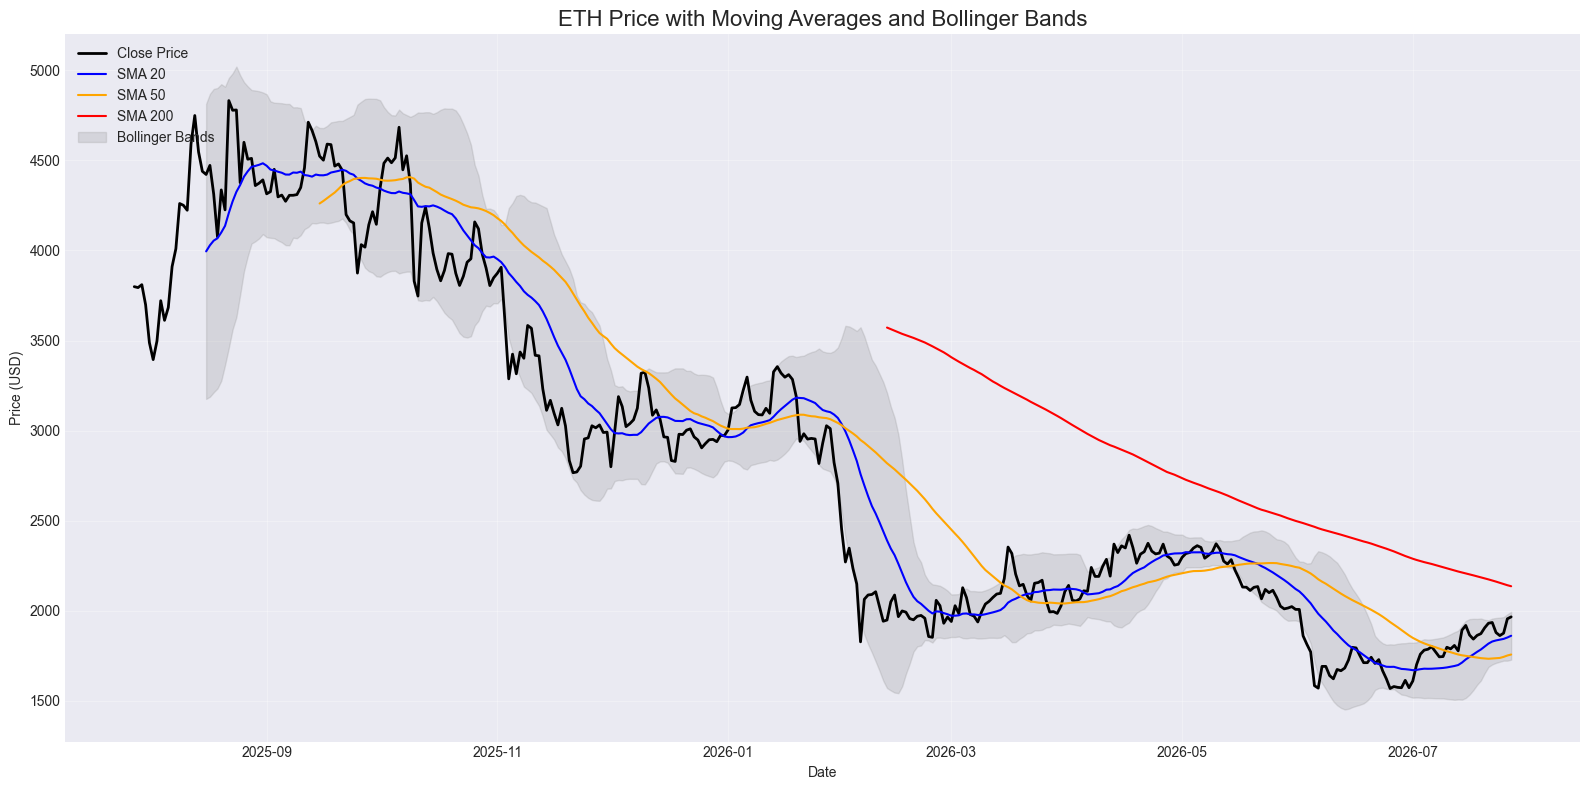

In [4]:
fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(df['date'], df['close'], label='Close Price', color='black', linewidth=2)
ax.plot(df['date'], df['SMA_20'], label='SMA 20', color='blue', linewidth=1.5)
ax.plot(df['date'], df['SMA_50'], label='SMA 50', color='orange', linewidth=1.5)
ax.plot(df['date'], df['SMA_200'], label='SMA 200', color='red', linewidth=1.5)

ax.fill_between(df['date'], df['BB_lower'], df['BB_upper'], 
                 alpha=0.2, color='gray', label='Bollinger Bands')

ax.set_title('ETH Price with Moving Averages and Bollinger Bands', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. MACD Indicator

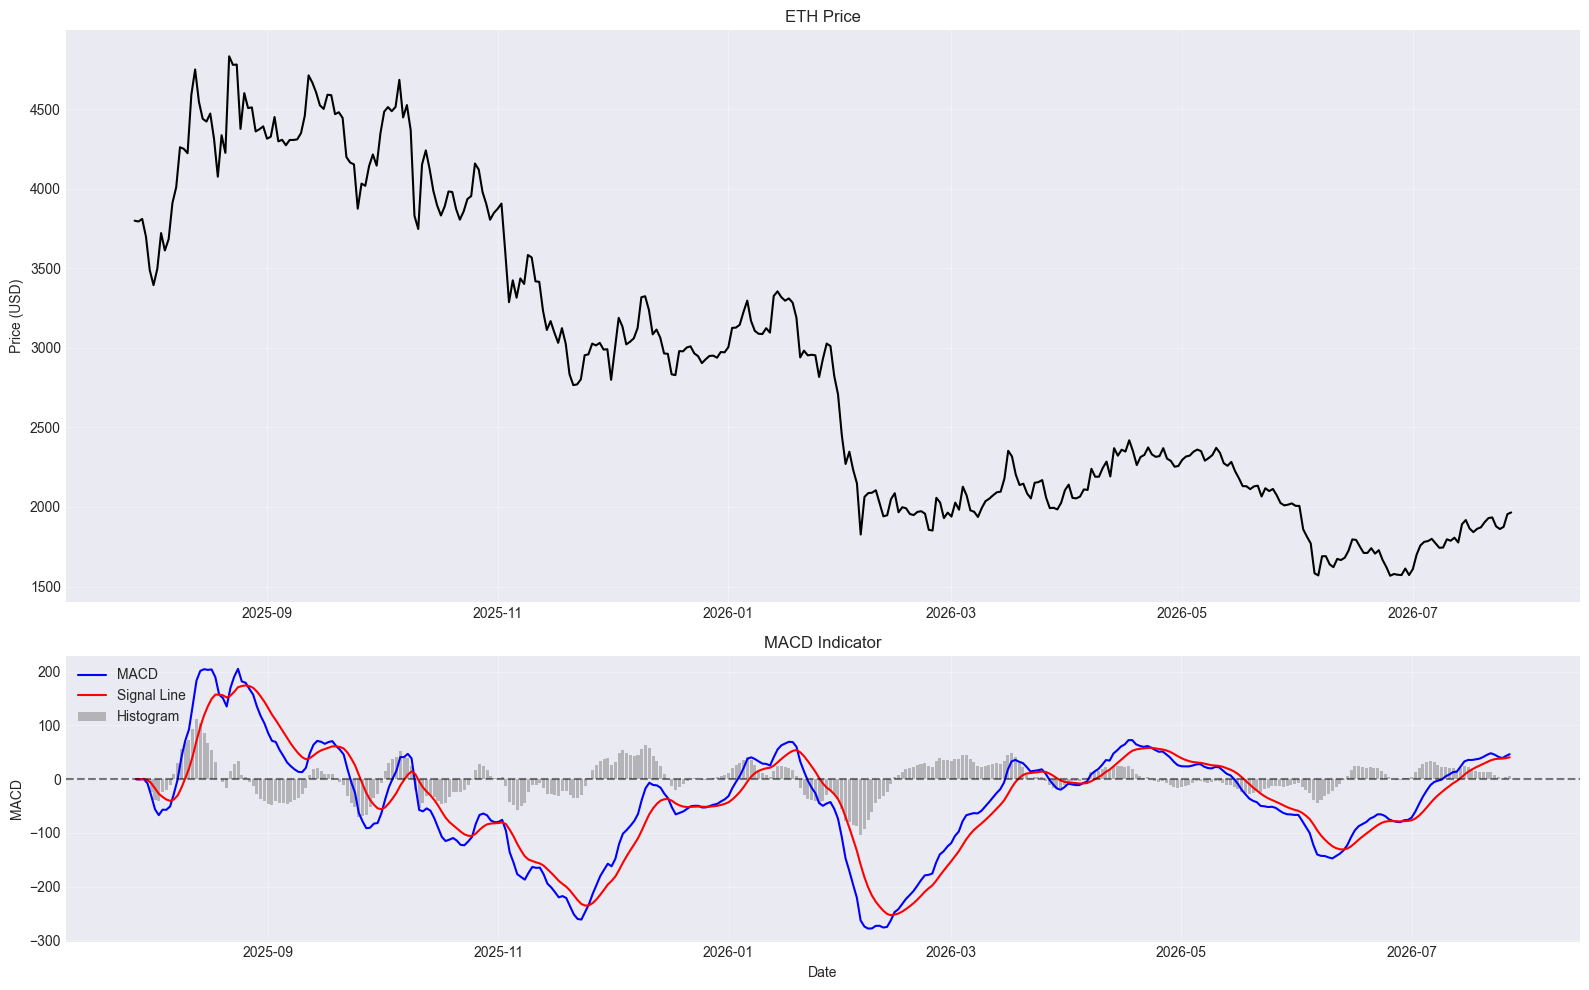

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [2, 1]})

# Price
axes[0].plot(df['date'], df['close'], label='Close Price', color='black', linewidth=1.5)
axes[0].set_title('ETH Price')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True, alpha=0.3)

# MACD
axes[1].plot(df['date'], df['MACD'], label='MACD', color='blue', linewidth=1.5)
axes[1].plot(df['date'], df['MACD_signal'], label='Signal Line', color='red', linewidth=1.5)
axes[1].bar(df['date'], df['MACD_hist'], label='Histogram', color='gray', alpha=0.5)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('MACD Indicator')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('MACD')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. RSI and Volume

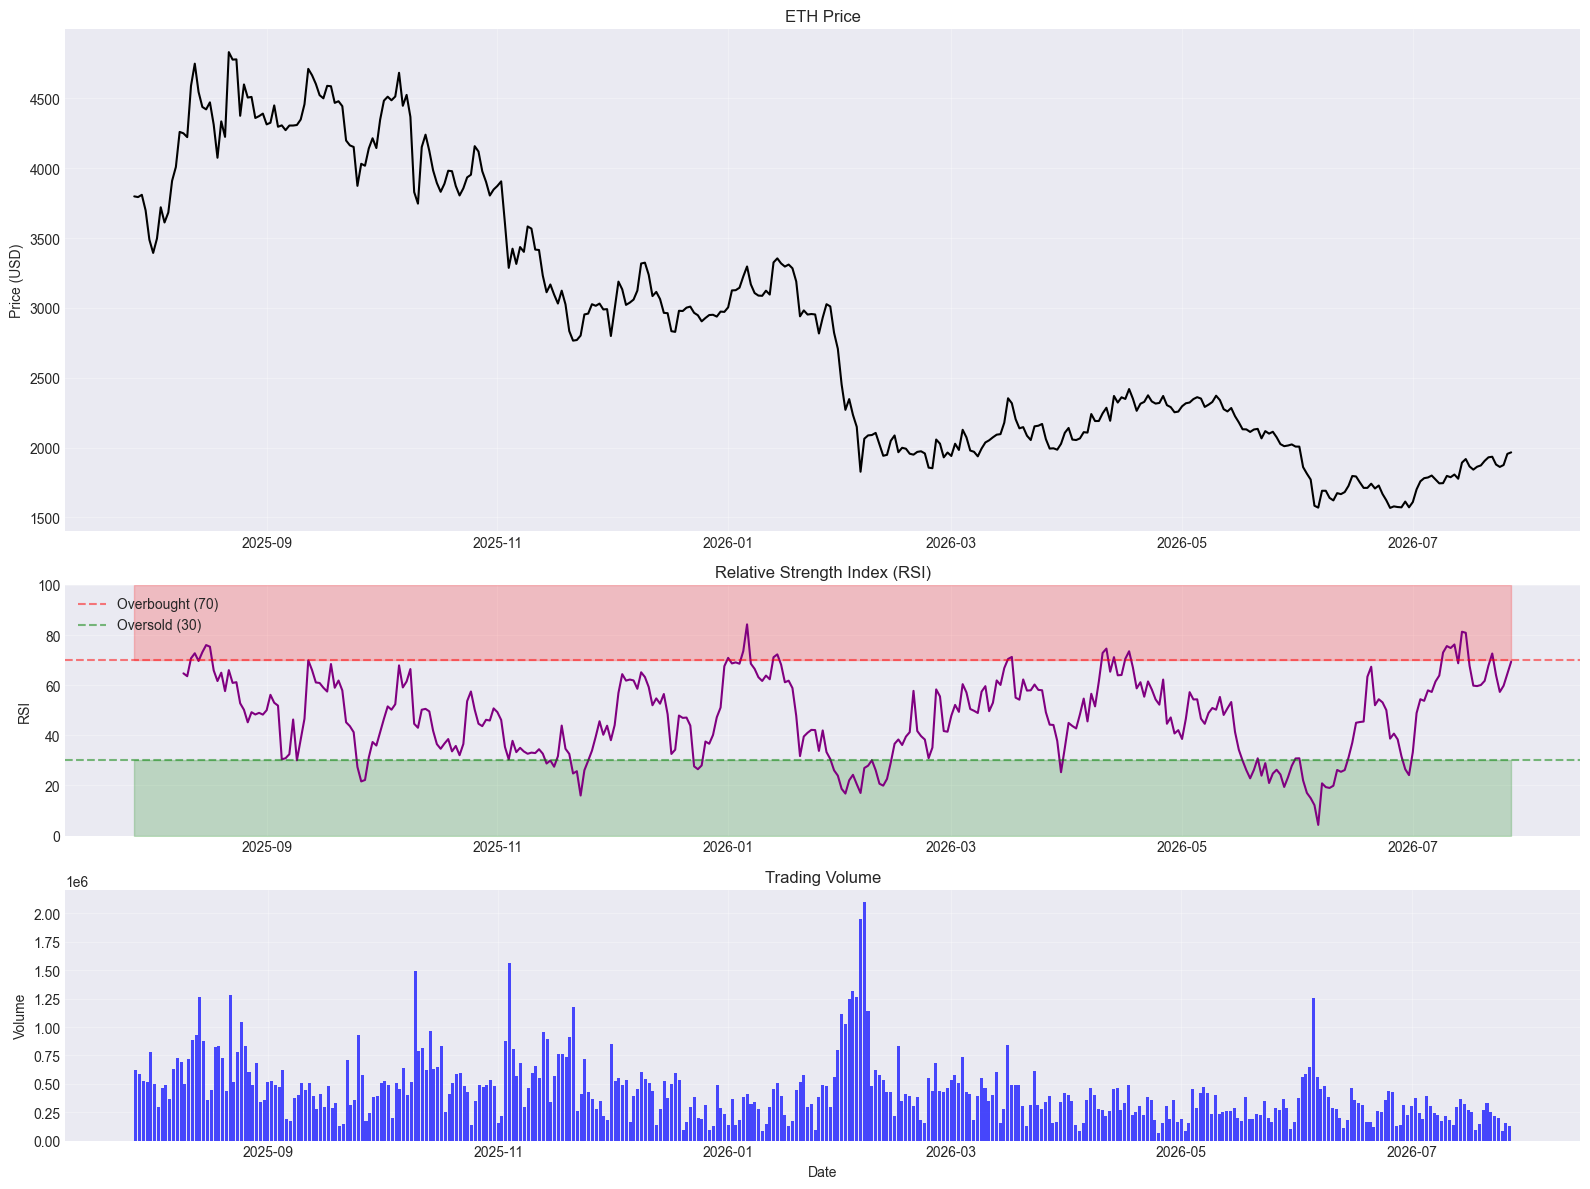

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [2, 1, 1]})

# Price
axes[0].plot(df['date'], df['close'], color='black', linewidth=1.5)
axes[0].set_title('ETH Price')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(True, alpha=0.3)

# RSI
axes[1].plot(df['date'], df['RSI_14'], color='purple', linewidth=1.5)
axes[1].axhline(y=70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
axes[1].axhline(y=30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
axes[1].fill_between(df['date'], 70, 100, alpha=0.2, color='red')
axes[1].fill_between(df['date'], 0, 30, alpha=0.2, color='green')
axes[1].set_title('Relative Strength Index (RSI)')
axes[1].set_ylabel('RSI')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# Volume
axes[2].bar(df['date'], df['volume'], color='blue', alpha=0.7)
axes[2].set_title('Trading Volume')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Volume')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Generate Trading Signals

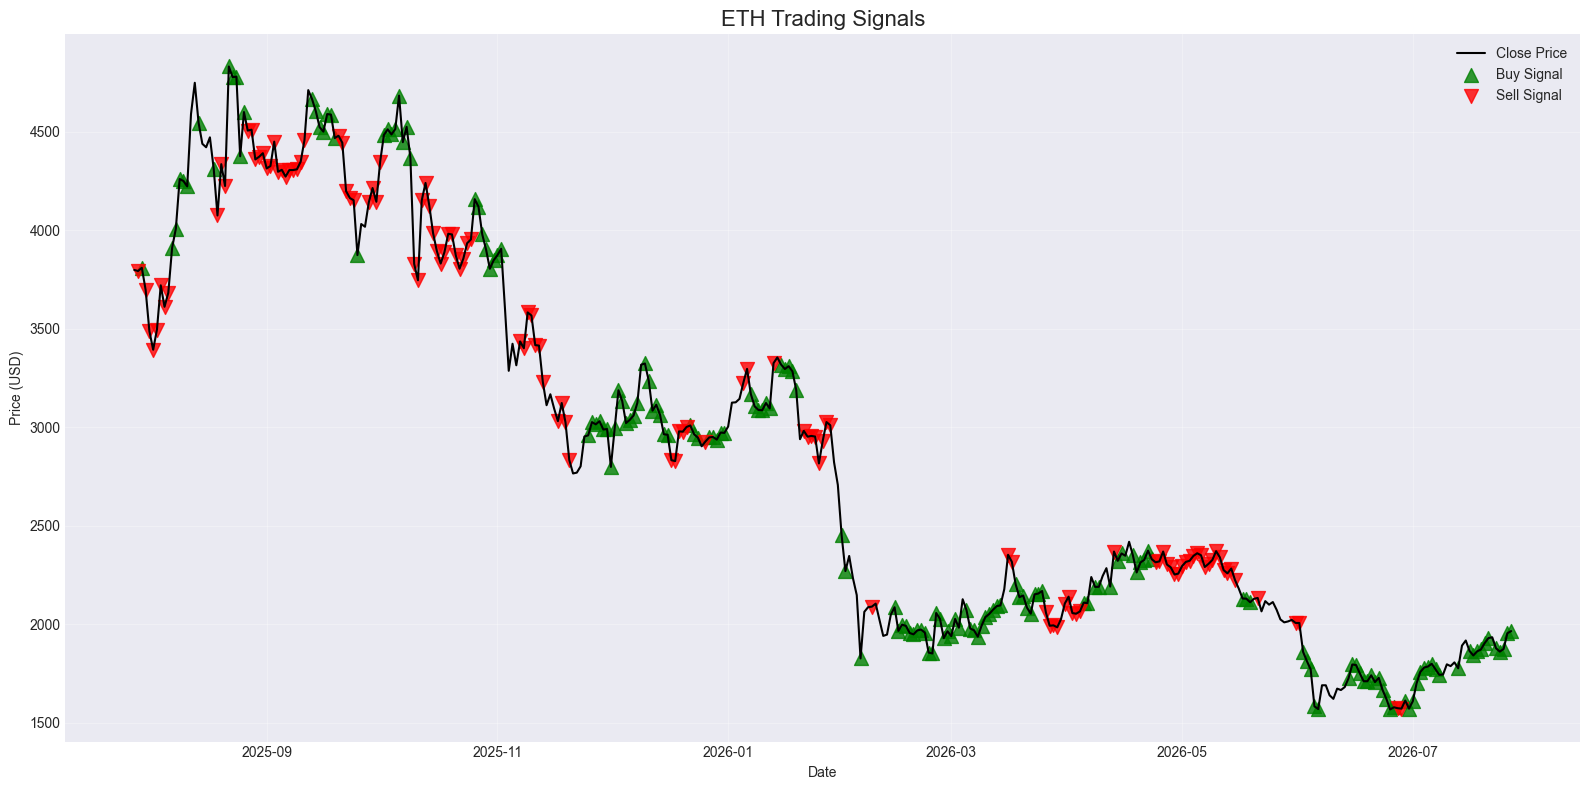

📊 Signal Summary:
   Buy Signals: 172
   Sell Signals: 120
   Neutral: 73


In [7]:
def generate_signals(df):
    """Generate trading signals"""
    df = df.copy()
    df['signal'] = 0
    
    # MACD crossover
    df.loc[df['MACD'] > df['MACD_signal'], 'signal'] += 1
    df.loc[df['MACD'] < df['MACD_signal'], 'signal'] -= 1
    
    # RSI signals
    df.loc[df['RSI_14'] < 30, 'signal'] += 1
    df.loc[df['RSI_14'] > 70, 'signal'] -= 1
    
    # Bollinger Bands
    df.loc[df['close'] < df['BB_lower'], 'signal'] += 1
    df.loc[df['close'] > df['BB_upper'], 'signal'] -= 1
    
    return df

df_signals = generate_signals(df)

fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(df_signals['date'], df_signals['close'], label='Close Price', color='black', linewidth=1.5)

buy_signals = df_signals[df_signals['signal'] > 0]
ax.scatter(buy_signals['date'], buy_signals['close'], 
           color='green', s=100, marker='^', label='Buy Signal', alpha=0.8)

sell_signals = df_signals[df_signals['signal'] < 0]
ax.scatter(sell_signals['date'], sell_signals['close'], 
           color='red', s=100, marker='v', label='Sell Signal', alpha=0.8)

ax.set_title('ETH Trading Signals', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("📊 Signal Summary:")
print(f"   Buy Signals: {(df_signals['signal'] > 0).sum()}")
print(f"   Sell Signals: {(df_signals['signal'] < 0).sum()}")
print(f"   Neutral: {(df_signals['signal'] == 0).sum()}")

## 8. Save Trading Signals to SQLite

In [8]:
# Save signals to SQLite
conn = sqlite3.connect(db_path)

conn.execute('''
    CREATE TABLE IF NOT EXISTS eth_signals (
        date TEXT PRIMARY KEY,
        signal INTEGER,
        signal_type TEXT
    )
''')

df_signals_db = df_signals[['date', 'signal']].copy()
df_signals_db['date'] = df_signals_db['date'].dt.strftime('%Y-%m-%d')
df_signals_db['signal_type'] = df_signals_db['signal'].apply(
    lambda x: 'BUY' if x > 0 else ('SELL' if x < 0 else 'NEUTRAL')
)

df_signals_db.to_sql('eth_signals', conn, if_exists='replace', index=False)
conn.close()

print("✅ Trading signals saved to SQLite")
df_signals_db.tail()

✅ Trading signals saved to SQLite


,date,signal,signal_type
360,2026-07-23,1,BUY
361,2026-07-24,1,BUY
362,2026-07-25,1,BUY
363,2026-07-26,1,BUY
364,2026-07-27,1,BUY
